In [ ]:
import unittest
import sys
import os
import copy
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
print(sys.version)
print(sys.executable)


sys.path.append("/Net/Groups/BSI/work_scratch/ppapastefanou/src/PlantHydraulicStandalone")
from src.contrib.swiss_tree_parser import SwissTreeParser
from src.contrib.auxil.setups import Setup
from src.contrib.auxil.output_df import create_output_df
from src.contrib.auxil.files import get_trees_psi_leaf_folder_path_cc
from src.contrib.config import Config, Swiss_soil_water_input_type

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_other_soil_other_cstem"
scenario_name = "big_overview_20_10000p"
root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2024_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_relay"

root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon_2025_final"
scenario_name = "big_overview_20_10000p_fine_g1fix_h_kxylem"

root_output_directory = "/Net/Groups/BSI/scratch/ppapastefanou/simulations/SimPHony/swiss_cc/"
scenario_name = "19_ex_con_2025_full_logit_mean_one"

scenario_name = "21_ex_con_2025_full_logit_mean_one_wcont"
# root_output_directory = "/Users/pp/data/Simulations/A08_SimPHony/swiss/excon"
# scenario_name = "old_params_extensive"

input_path = os.path.join(root_output_directory, scenario_name, 'input')
output_path = os.path.join(root_output_directory, scenario_name, 'output')
post_path = os.path.join(root_output_directory, scenario_name, 'post')

setup = Setup()
setup.Apply_default_swiss(Swiss_soil_water_input_type.OneLayer_Mean_One_Std)
setup.Apply_default_paths(root_output_directory, scenario_name)
setup.config.parameters_list_file = os.path.join(setup.config.post_path, "parameters_best_mean_alive.csv")
setup.config.config_file = os.path.join("config_dummy.txt")
# Specifying forcing and evalution data paths
#setup.Export()

# Read in the Swiss trees
tree_parser = SwissTreeParser(get_trees_psi_leaf_folder_path_cc())

print(setup.config.build_folder)

sys.path.append("/Net/Groups/BSI/work_scratch/ppapastefanou/src/PlantHydraulicStandalone/build")
from SimPHony import Simulation_Single_Swiss
from SimPHony import DateTime



selective_range = ['mean_alive', 0,3, 6, 7]
#selective_range = [0, 4, 6, 7]
ax_indexes =[1,2,3,4,5]
N_BEST = 10

3.12.10 | packaged by conda-forge | (main, Apr 10 2025, 22:21:13) [GCC 13.3.0]
/Net/Groups/BSI/work_scratch/ppapastefanou/envs/SimPHony_intel_mpich/bin/python
/Net/Groups/BSI/work_scratch/ppapastefanou/src/PlantHydraulicStandalone/src/contrib/auxil/../../../build


ImportError: libimf.so: cannot open shared object file: No such file or directory

In [7]:
for id, ai in zip(selective_range, ax_indexes) :
    if ai == 1:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Alive.csv")
    else:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Dead{ai-1}.csv")
    print(pd.read_csv(setup.config.parameters_list_file).shape)

(6501, 74)
(6501, 74)
(6501, 74)
(6501, 74)
(6501, 74)


In [8]:

ncombs = pd.read_csv(setup.config.parameters_list_file).shape[0]

step = int(ncombs/100)


dead_ids =[0,3,6,7]
df_ax_m = {}
df_ax_ql = {}
df_ax_qu = {}

df_ax_m24 = {}
df_ax_ql24 = {}
df_ax_qu24 = {}

trees = {}
for id, ai in zip(selective_range, ax_indexes):

    if ai == 1:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Alive.csv")
    else:
        setup.config.parameters_list_file = os.path.join(setup.config.post_path, f"Dead{ai-1}.csv")

    setup.Export()

    for j in range(0, ncombs, step):

        # ----------------------------------------------------------------
        # PHS model simulation
        # ----------------------------------------------------------------

        # Specify Start and End of the Simulation
        format = "%Y-%m-%d %H:%M:%S"
        date_start_str = "2018-05-01 00:00:00"
        date_end_str = "2018-12-15 00:00:00"
        timestart = DateTime(date_start_str, format)
        timeend = DateTime(date_end_str, format)

        # Set up the PHS simulation
        # read in the parameter file that we just created
        sim = Simulation_Single_Swiss()
        sim.Read_config(setup.config.config_file)
        sim.Init_eval(timestart, timeend)
        sim.Init_parameters_fn_single(j)
        sim.Init_input()
        sim.Set_water_pot_initials(-1.0, -0.2)

        # Run the simulation
        sim.Run(timestart, timeend)
        sim.Analyse()

        # Get output and analysis data
        # output = sim.Get_output()
        an = sim.Get_analysis()
        errors = an.Get_rmse()

        # Getting the raw output data
        output = sim.Get_output()
        # Getting the raw analysis data
        an = sim.Get_analysis()
        

        # Creating pandas dataframe
        df_mod = create_output_df(output, date_start_str)

        df_mod['id'] = int(j)
        
        rmse = an.Get_rmse()
        if ai == 1:
            df_mod['rmse'] = np.mean(np.array(rmse)[[1, 4, 9, 10, 11, 12, 13]])
        else:
            df_mod['rmse'] = rmse[id]


        
        if j == 0:
            df_d = df_mod
        else:
            df_d = pd.concat([df_d, df_mod], axis=0)
        print(j)

    # ----------------------------------------------------------------
    # Plotting model output
    # ----------------------------------------------------------------

    if id == 'mean_alive':
        tree_df = tree_parser.df_alive_all
    else:
        tree_df = tree_parser.trees[id].df
      
    trees[ai] = tree_df   
    dm = df_d.groupby(df_d.index).median()
    d25 = df_d.groupby(df_d.index).quantile(0.1)
    d75 = df_d.groupby(df_d.index).quantile(0.9)

    df_ax_m[ai] = dm
    df_ax_ql[ai] = d25
    df_ax_qu[ai] = d75
    
    dfm = df_d.groupby([df_d.index.hour, df_d.index.minute]).mean()
    dfql = df_d.groupby([df_d.index.hour, df_d.index.minute]).quantile(0.1)
    dfqu = df_d.groupby([df_d.index.hour, df_d.index.minute]).quantile(0.9)
    
    df_ax_m24[ai] = dfm
    df_ax_ql24[ai] = dfql
    df_ax_qu24[ai] = dfqu


0
65
130
195
260
325
390
455
520
585
650
715
780
845
910
975
1040
1105
1170
1235
1300
1365
1430
1495
1560
1625
1690
1755
1820
1885
1950
2015
2080
2145
2210
2275
2340
2405
2470
2535
2600
2665
2730
2795
2860
2925
2990
3055
3120
3185
3250
3315
3380
3445
3510
3575
3640
3705
3770
3835
3900
3965
4030
4095
4160
4225
4290
4355
4420
4485
4550
4615
4680
4745
4810
4875
4940
5005
5070
5135
5200
5265
5330
5395
5460
5525
5590
5655
5720
5785
5850
5915
5980
6045
6110
6175
6240
6305
6370
6435
6500
0
65
130
195
260
325
390
455
520
585
650
715
780
845
910
975
1040
1105
1170
1235
1300
1365
1430
1495
1560
1625
1690
1755
1820
1885
1950
2015
2080
2145
2210
2275
2340
2405
2470
2535
2600
2665
2730
2795
2860
2925
2990
3055
3120
3185
3250
3315
3380
3445
3510
3575
3640
3705
3770
3835
3900
3965
4030
4095
4160
4225
4290
4355
4420
4485
4550
4615
4680
4745
4810
4875
4940
5005
5070
5135
5200
5265
5330
5395
5460
5525
5590
5655
5720
5785
5850
5915
5980
6045
6110
6175
6240
6305
6370
6435
6500
0
65
130
195
260
325
390
455

In [4]:
print(np.round(df_ax_m[1]['rmse'].iloc[0],2))
print(np.round(df_ax_m[1]['rmse'].iloc[1000],2))

0.51
0.51


In [5]:
print(np.round(df_ax_ql[1]['rmse'].iloc[0],2))
print(np.round(df_ax_m[1]['rmse'].iloc[0],2))
print(np.round(df_ax_qu[1]['rmse'].iloc[0],2))


0.48
0.51
0.52


In [6]:
print(np.round(df_ax_ql[1]['psiLeaf'].mean(),2))
print(np.round(df_ax_m[1]['psiLeaf'].mean(),2))
print(np.round(df_ax_qu[1]['psiLeaf'].mean(),2))

-1.35
-1.24
-1.15


In [7]:
print(np.round(df_ax_ql[1]['psiSap'].mean(),2))
print(np.round(df_ax_m[1]['psiSap'].mean(),2))
print(np.round(df_ax_qu[1]['psiSap'].mean(),2))

-0.8
-0.7
-0.6


In [8]:
print(np.round(df_ax_ql[1]['psiSoilUp'].mean(),2))
print(np.round(df_ax_m[1]['psiSoilUp'].mean(),2))
print(np.round(df_ax_qu[1]['psiSoilUp'].mean(),2))

-0.9
-0.7
-0.54


In [9]:
print(np.round(df_ax_ql[1]['gss'].mean(),3))
print(np.round(df_ax_m[1]['gss'].mean(),3))
print(np.round(df_ax_qu[1]['gss'].mean(),3))

0.011
0.014
0.017


In [9]:
print(np.round(df_ax_m[1]['vpd'].mean(),2))

617.11


In [10]:
print(np.round(df_ax_ql[1]['T'].mean(),6))
print(np.round(df_ax_m[1]['T'].mean(),6))
print(np.round(df_ax_qu[1]['T'].mean(),6))

0.000112
0.000146
0.000178


In [11]:
print(np.round(df_ax_ql[1]['G'].mean(),6))
print(np.round(df_ax_m[1]['G'].mean(),6))
print(np.round(df_ax_qu[1]['G'].mean(),6))

8.8e-05
0.000143
0.00021


In [12]:
dfm = df_ax_m[1].groupby([df_ax_m[1].index.hour, df_ax_m[1].index.minute]).mean()
dfql = df_ax_ql[1].groupby([df_ax_ql[1].index.hour, df_ax_ql[1].index.minute]).mean()
dfqu = df_ax_qu[1].groupby([df_ax_qu[1].index.hour, df_ax_qu[1].index.minute]).mean()

In [31]:
df_ax_m24[1]

DeltaT          vpd       ksSoil0  psiSoilUp    psiSap  \
date date                                                              
0    0     9806400.0   423.307291  2.523462e-09  -0.657458 -0.708570   
     30    9808200.0   406.477329  2.527299e-09  -0.657777 -0.707507   
1    0     9810000.0   389.647363  2.531588e-09  -0.658113 -0.706444   
     30    9811800.0   374.269320  2.536340e-09  -0.658468 -0.705381   
2    0     9813600.0   358.891276  2.541566e-09  -0.658840 -0.704317   
     30    9815400.0   346.279453  2.536074e-09  -0.658421 -0.703323   
3    0     9817200.0   333.667631  2.530941e-09  -0.658032 -0.702363   
     30    9819000.0   322.745819  2.526176e-09  -0.657670 -0.701438   
4    0     9820800.0   311.824004  2.521788e-09  -0.657335 -0.700544   
     30    9822600.0   304.266448  2.517787e-09  -0.657026 -0.699774   
5    0     9824400.0   296.708889  2.514184e-09  -0.656742 -0.699095   
     30    9826200.0   300.871641  2.510990e-09  -0.656483 -0.698656   
6    0     9828000.0   305.034392  2.508217e-09  -0.656246 -0.698405   
     30    9829800.0   334.217175  2.505876e-09  -0.656033 -0.698451   
7    0     9831600.0   363.399956  2.503982e-09  -0.655841 -0.698701   
     30    9833400.0   408.419250  2.502549e-09  -0.655670 -0.699042   
8    0     9835200.0   453.438544  2.501590e-09  -0.655520 -0.699569   
     30    9837000.0   507.527773  2.501121e-09  -0.655391 -0.700299   
9    0     9838800.0   561.617006  2.501159e-09  -0.655280 -0.701199   
     30    9840600.0   621.628042  2.501720e-09  -0.655188 -0.702275   
10   0     9842400.0   681.639078  2.502823e-09  -0.655115 -0.703501   
     30    9844200.0   741.324837  2.504487e-09  -0.655060 -0.704887   
11   0     9846000.0   801.010598  2.506732e-09  -0.655022 -0.706407   
     30    9847800.0   855.458624  2.509579e-09  -0.655001 -0.708030   
12   0     9849600.0   909.906646  2.513051e-09  -0.654996 -0.709719   
     30    9851400.0   946.504919  2.517172e-09  -0.655007 -0.711463   
13   0     9853200.0   983.103192  2.521967e-09  -0.655035 -0.713236   
     30    9855000.0  1004.982444  2.527462e-09  -0.655077 -0.715022   
14   0     9856800.0  1026.861690  2.533685e-09  -0.655135 -0.716761   
     30    9858600.0  1040.109701  2.530086e-09  -0.654917 -0.718418   
15   0     9860400.0  1053.357709  2.526801e-09  -0.654738 -0.719921   
     30    9862200.0  1037.477477  2.523837e-09  -0.654596 -0.721167   
16   0     9864000.0  1021.597257  2.521197e-09  -0.654489 -0.722047   
     30    9865800.0   979.093984  2.518886e-09  -0.654416 -0.722613   
17   0     9867600.0   936.590722  2.516910e-09  -0.654375 -0.722787   
     30    9869400.0   878.173480  2.515273e-09  -0.654365 -0.722579   
18   0     9871200.0   819.756237  2.513982e-09  -0.654384 -0.721943   
     30    9873000.0   756.448876  2.513041e-09  -0.654433 -0.721018   
19   0     9874800.0   693.141523  2.512458e-09  -0.654508 -0.719795   
     30    9876600.0   645.265584  2.512237e-09  -0.654610 -0.718557   
20   0     9878400.0   597.389650  2.512387e-09  -0.654737 -0.717273   
     30    9880200.0   568.442279  2.512913e-09  -0.654889 -0.716060   
21   0     9882000.0   539.494910  2.513824e-09  -0.655065 -0.714889   
     30    9883800.0   517.204012  2.515125e-09  -0.655263 -0.713756   
22   0     9885600.0   494.913114  2.516825e-09  -0.655483 -0.712647   
     30    9887400.0   474.637653  2.518933e-09  -0.655724 -0.711555   
23   0     9889200.0   454.362191  2.521455e-09  -0.655986 -0.710474   
     30    9891000.0   438.628858  2.524403e-09  -0.656268 -0.709403   

           psiHeart   psiLeaf         T         G         J    O  J_apdated  \
date date                                                                     
0    0         -0.2 -1.065945  0.000009  0.000064  0.000009  0.0   0.000059   
     30        -0.2 -1.064234  0.000009  0.000064  0.000009  0.0   0.000056   
1    0         -0.2 -1.062621  0.000008  0.000064  0.000008  0.0   0.000054   
     30        -0.

In [ ]:
df_ax_m[1]

dict_keys([1, 2, 3, 4, 5])

(array([17652., 17656., 17660., 17664., 17668., 17672., 17676., 17680.,
        17683.]),
 [Text(17652.0, 0, '2018-05-01'),
  Text(17656.0, 0, '2018-05-05'),
  Text(17660.0, 0, '2018-05-09'),
  Text(17664.0, 0, '2018-05-13'),
  Text(17668.0, 0, '2018-05-17'),
  Text(17672.0, 0, '2018-05-21'),
  Text(17676.0, 0, '2018-05-25'),
  Text(17680.0, 0, '2018-05-29'),
  Text(17683.0, 0, '2018-06-01')])

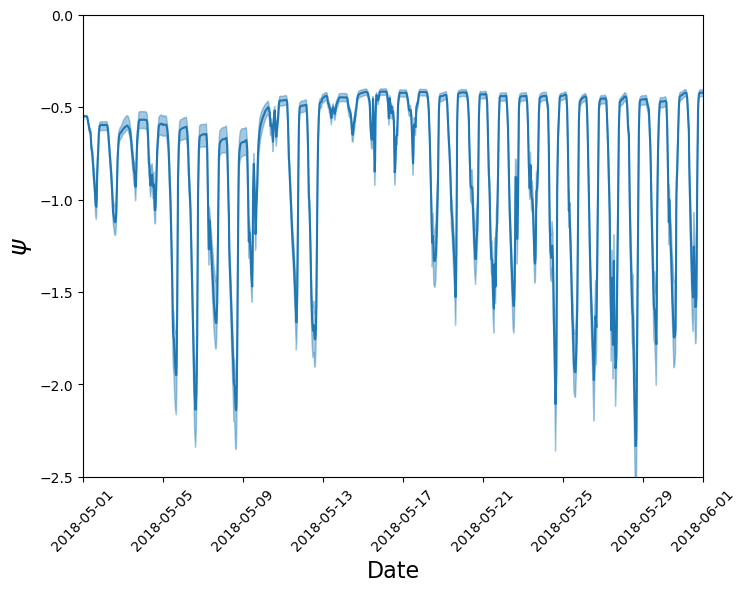

In [23]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
# ax.plot(df_ax_m[ii]['psiSap'], zorder =1, c = 'tab:brown')
# ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiSap'], df_ax_qu[ii]['psiSap'], zorder =1, color = 'tab:brown' ,alpha=0.4)
# ax.plot(df_ax_m[ii]['psiHeart'], zorder =1, c = 'pink')
# ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiHeart'], df_ax_qu[ii]['psiHeart'], zorder =1, color = 'pink' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-06-01'))
ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)

In [27]:
ii = 1
df_ax_m[ii]['psiLeaf']



date
2018-05-01 00:00:00   -0.575067
2018-05-01 00:30:00   -0.549626
2018-05-01 01:00:00   -0.547430
2018-05-01 01:30:00   -0.547963
2018-05-01 02:00:00   -0.548687
                         ...   
2018-12-14 21:30:00   -0.504556
2018-12-14 22:00:00   -0.504625
2018-12-14 22:30:00   -0.504655
2018-12-14 23:00:00   -0.504684
2018-12-14 23:30:00   -0.504673
Name: psiLeaf, Length: 10944, dtype: float64

In [ ]:
dls = df_ax_m[1]['psiLeaf'].loc[:'2018-05-31']
dlsm = dls.between_time('14:00', '14:00')
dlsm.describe()

count    31.000000
mean     -1.348442
std       0.478964
min      -2.110626
25%      -1.746923
50%      -1.363000
75%      -0.942356
max      -0.517136
Name: psiLeaf, dtype: float64

In [34]:
dls = df_ax_m[2]['psiLeaf'].loc[:'2018-05-31']
dlsm = dls.between_time('14:00', '14:00')
dlsm.describe()

count    31.000000
mean     -1.304114
std       0.253873
min      -1.658795
25%      -1.493495
50%      -1.314780
75%      -1.230870
max      -0.746078
Name: psiLeaf, dtype: float64

In [35]:
dls = df_ax_m[3]['psiLeaf'].loc[:'2018-05-31']
dlsm = dls.between_time('14:00', '14:00')
dlsm.describe()

count    31.000000
mean     -1.236013
std       0.276673
min      -1.683480
25%      -1.445923
50%      -1.257100
75%      -0.973478
max      -0.677244
Name: psiLeaf, dtype: float64

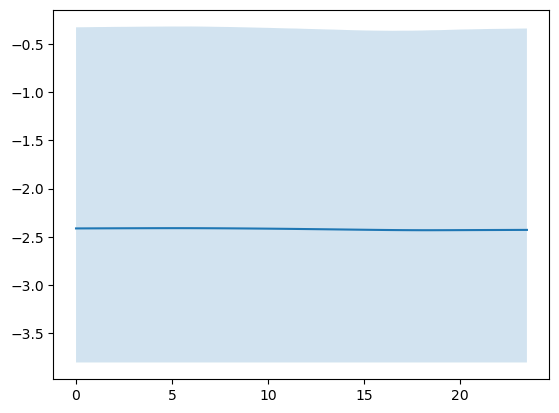

In [10]:
var = 'psiSap'
plt.plot(np.arange(0, 24, 0.5),dfm[var])
plt.fill_between(np.arange(0, 24, 0.5), dfql[var],dfqu[var], alpha=0.2)

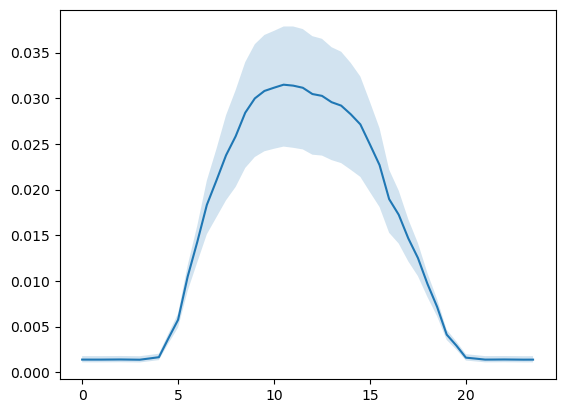

In [14]:
plt.plot(np.arange(0, 24, 0.5),dfm['gss'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['gss'],dfqu['gss'], alpha=0.2)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

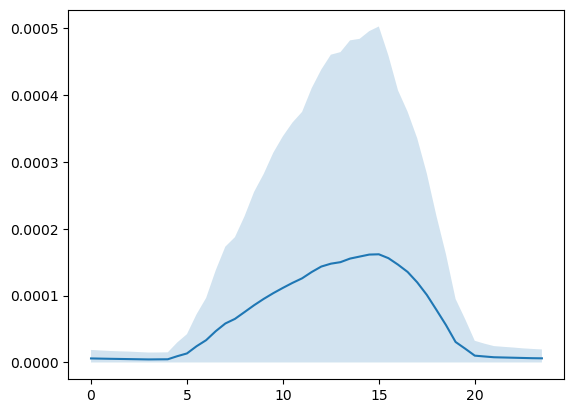

In [64]:
plt.plot(np.arange(0, 24, 0.5),dfm['T'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['T'],dfqu['T'], alpha=0.2)

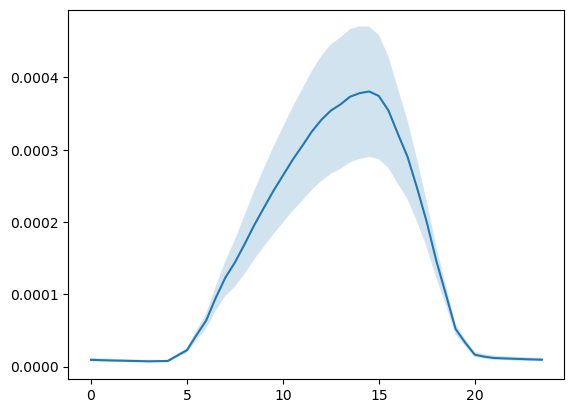

In [15]:
plt.plot(np.arange(0, 24, 0.5),dfm['J'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['J'],dfqu['J'], alpha=0.2)

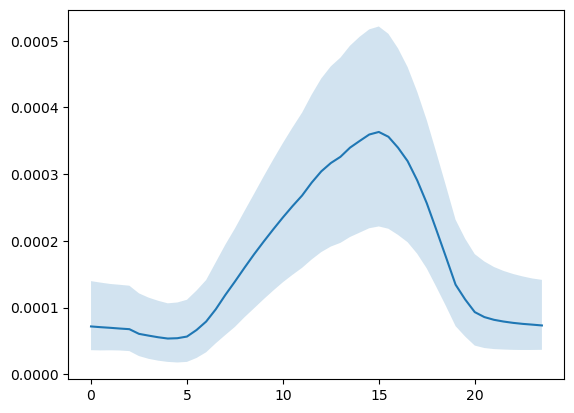

In [12]:
plt.plot(np.arange(0, 24, 0.5),dfm['G'])
plt.fill_between(np.arange(0, 24, 0.5), dfql['G'],dfqu['G'], alpha=0.2)

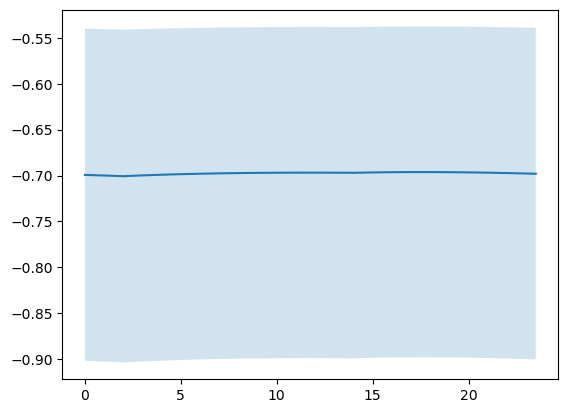

In [16]:
plt.fill_between(np.arange(0, 24, 0.5), dfql['psiSoilUp'], dfqu['psiSoilUp'], alpha=0.2)
plt.plot(np.arange(0, 24, 0.5), dfm['psiSoilUp'])


In [39]:
for i in [1, 2,4,5]:
    print(np.round(df_ax_ql[i]['rmse'].iloc[0],2))
    print(np.round(df_ax_m[i]['rmse'].iloc[0],2))
    print(np.round(df_ax_qu[i]['rmse'].iloc[0],2))
    print("")

0.48
0.5
0.52

0.47
0.52
0.64

0.78
0.86
1.08

0.62
0.66
0.82



(-7.0, 0.0)

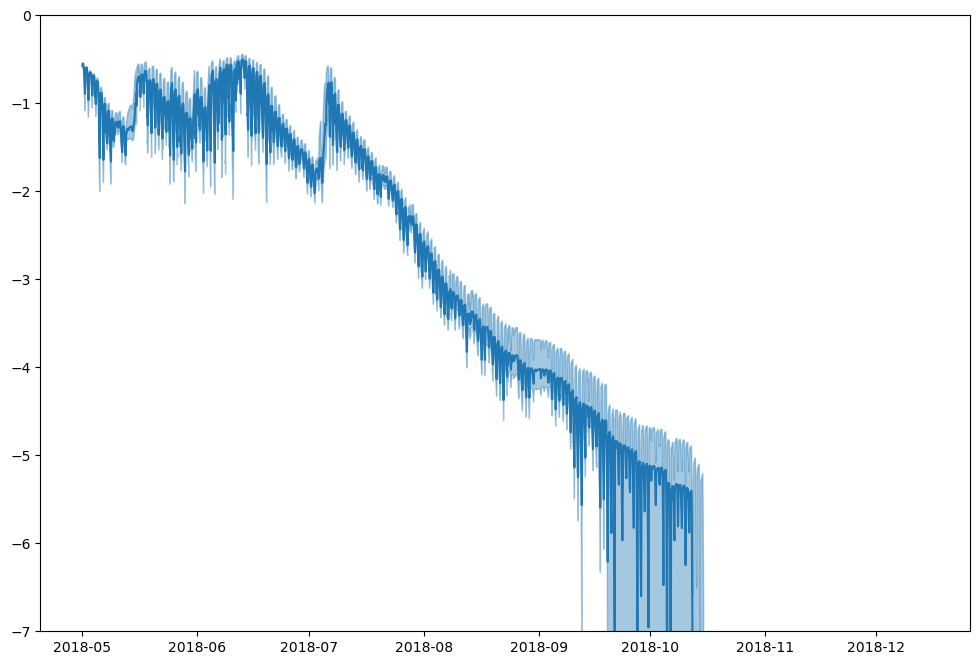

In [17]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(1,1, 1)
ax.plot(df_ax_m[2]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[2].index, df_ax_ql[2]['psiLeaf'], df_ax_qu[2]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ax.set_ylim(-7.0, 0)

In [ ]:
plt.rcParams["font.family"] = "Avenir"

"/User/homes/ppapastefanou/fonts/Avenir Next.ttc"

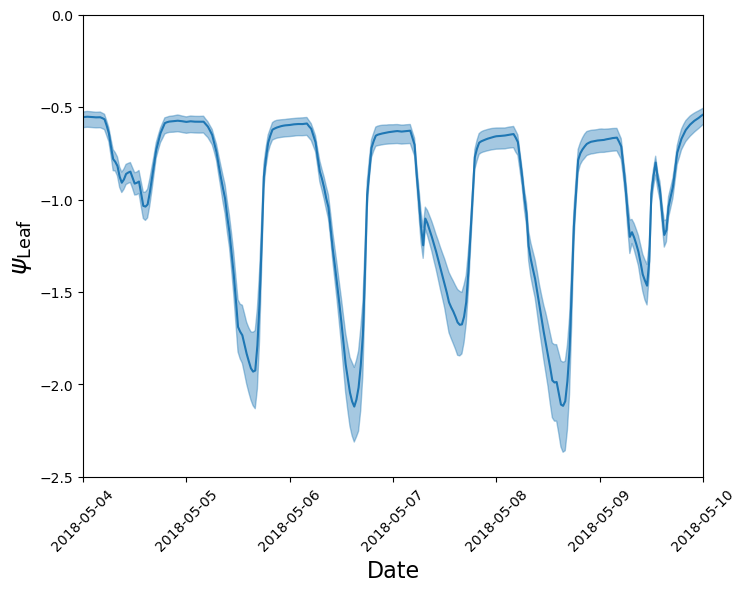

In [11]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-04'), pd.Timestamp('2018-05-10'))
ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize = 18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P1.png"), bbox_inches='tight', dpi = 300)

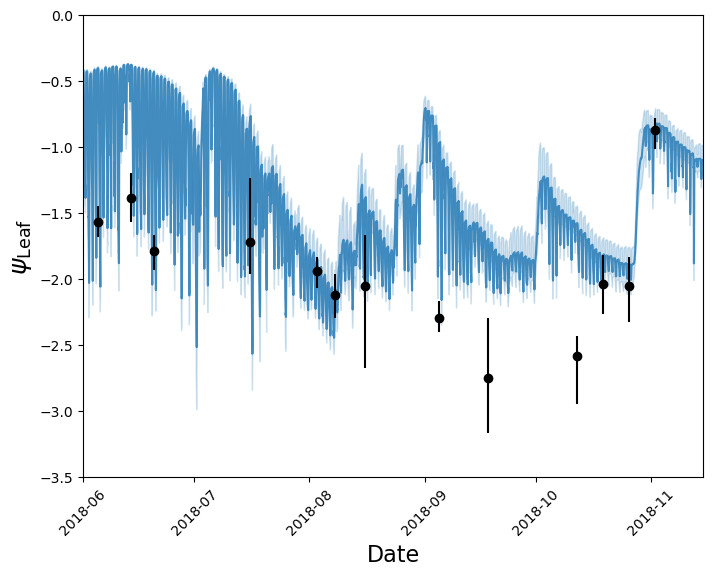

In [18]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:blue' ,alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:blue',
                alpha=0.2)
df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
df_tree_lower = trees[ii].groupby(trees[ii].index).min()
df_tree_upper = trees[ii].groupby(trees[ii].index).max()
ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                                       df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-11-15'))
plt.xticks(rotation=45)
ax.set_ylim(-3.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.savefig(os.path.join(post_path, "F1_P2.png"), bbox_inches='tight', dpi=300)

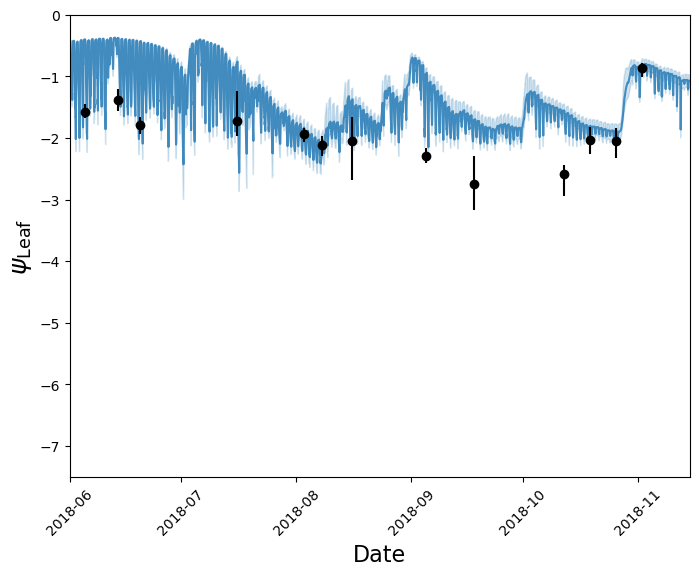

In [13]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:blue' ,alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:blue',
                alpha=0.2)
df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
df_tree_lower = trees[ii].groupby(trees[ii].index).min()
df_tree_upper = trees[ii].groupby(trees[ii].index).max()
ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                                       df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-11-15'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P3.png"), bbox_inches='tight', dpi=300)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

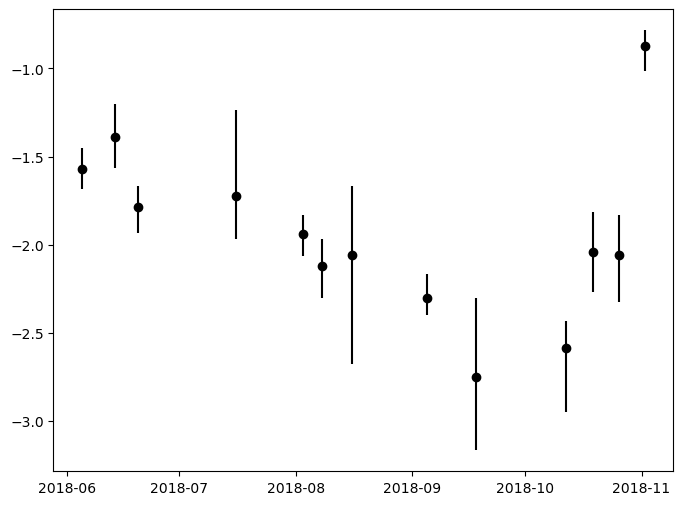

In [57]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
df_tree_lower = trees[ii].groupby(trees[ii].index).min()
df_tree_upper = trees[ii].groupby(trees[ii].index).max()
ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                                       df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
plt.show()

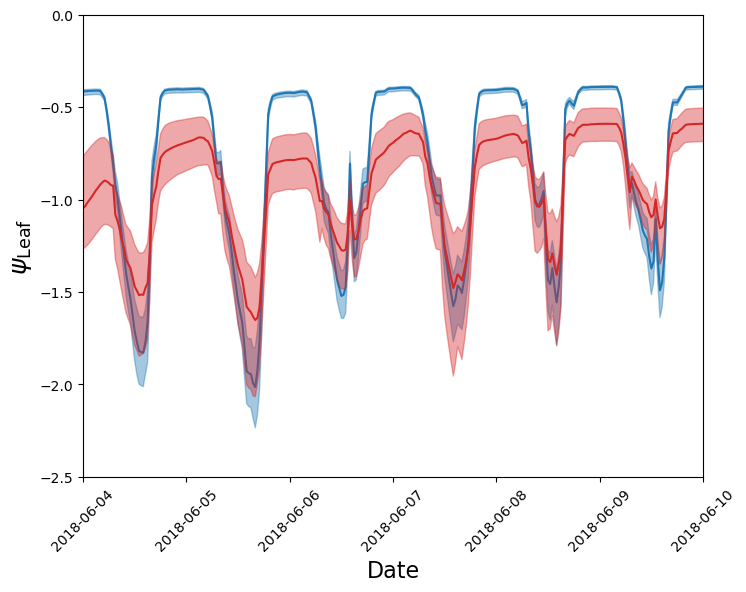

In [14]:

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ii = 2
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:red' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-06-04'), pd.Timestamp('2018-06-10'))
ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P4.png"), bbox_inches='tight', dpi=300)

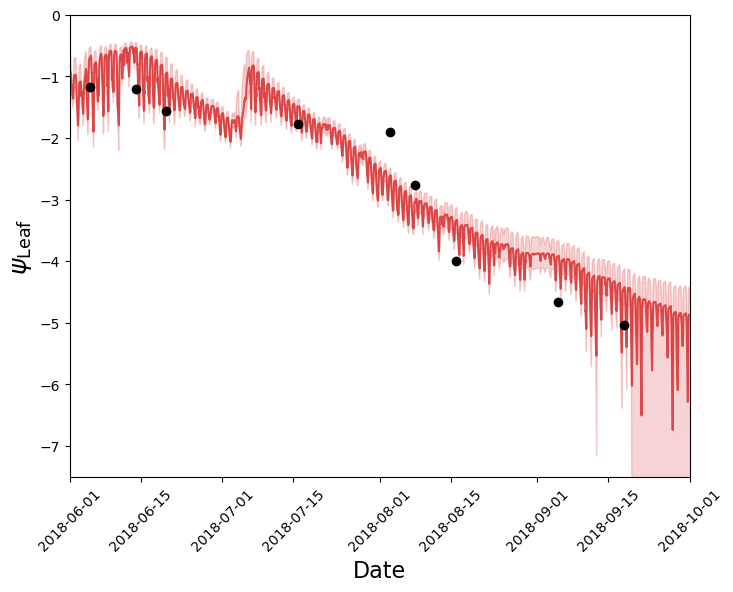

In [7]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P5.png"), bbox_inches='tight', dpi=300)

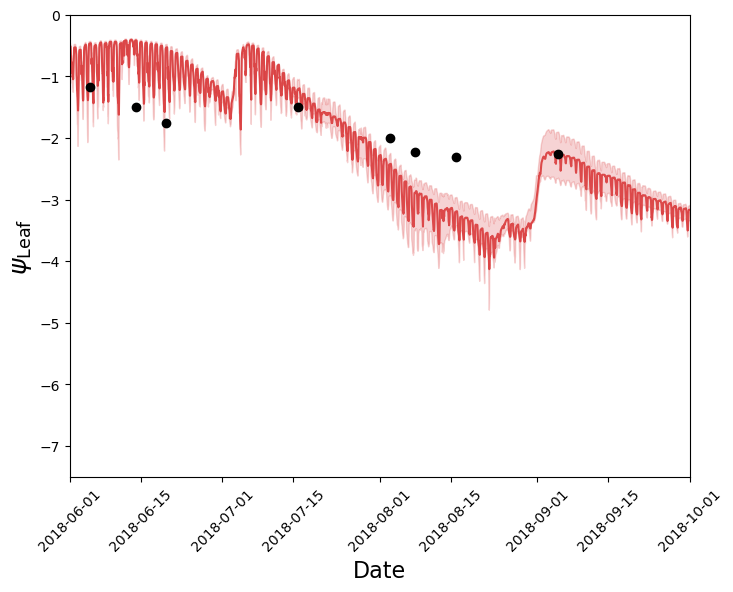

In [39]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 3
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P6.png"), bbox_inches='tight', dpi=300)

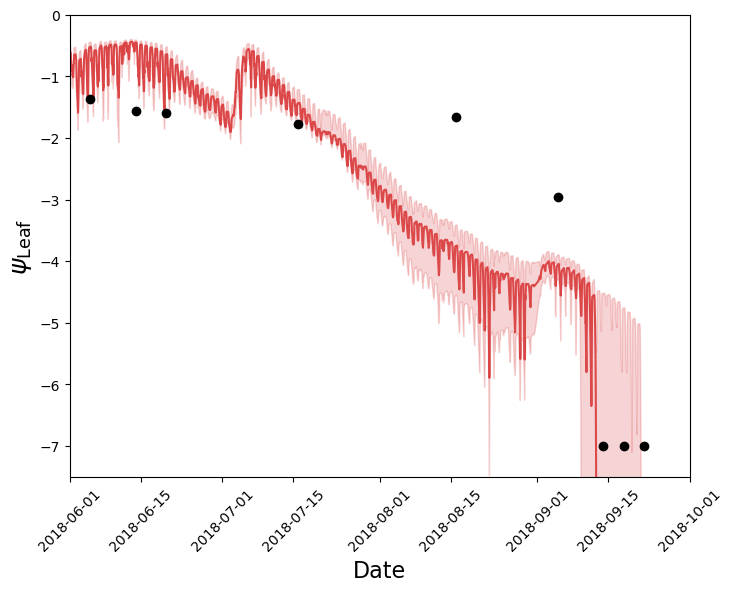

In [40]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 4
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P6.png"), bbox_inches='tight', dpi=300)


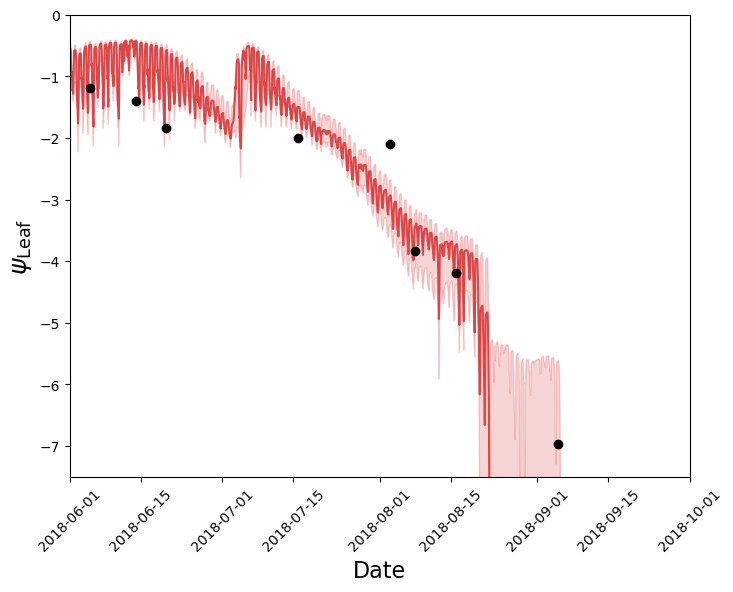

In [41]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red', alpha=0.8)
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2)
ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-7.5, 0)
ax.set_xlabel("Date", fontsize=16)
ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
plt.xticks(rotation=45)
plt.savefig(os.path.join(post_path, "F1_P7.png"), bbox_inches='tight', dpi=300)

KeyError: 6

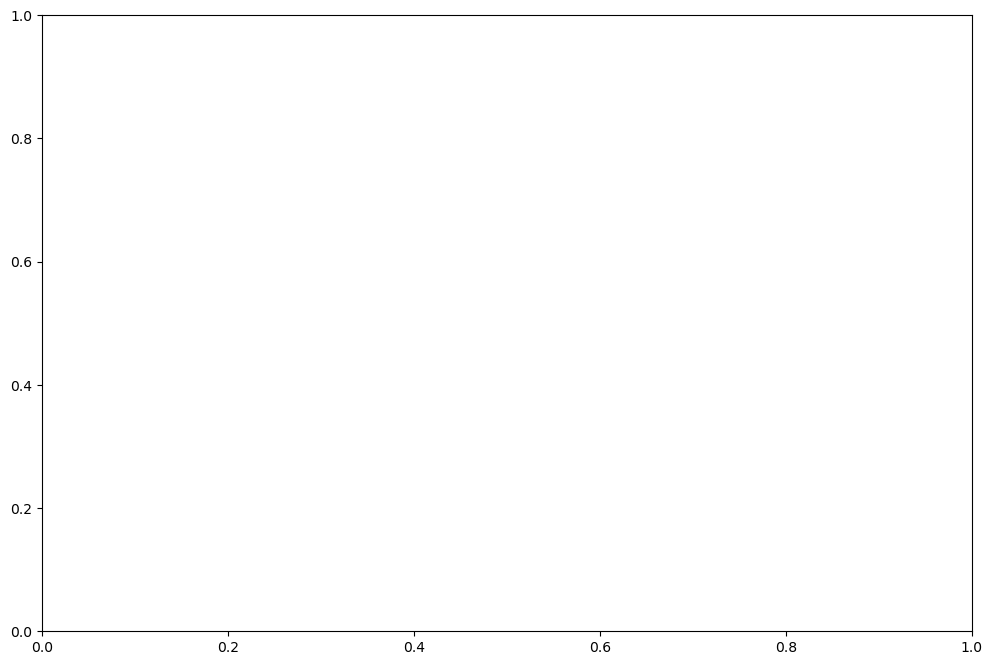

In [19]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(1,1, 1)
ii = 6
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:red' ,alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-8, 0)

(-8.0, 0.0)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

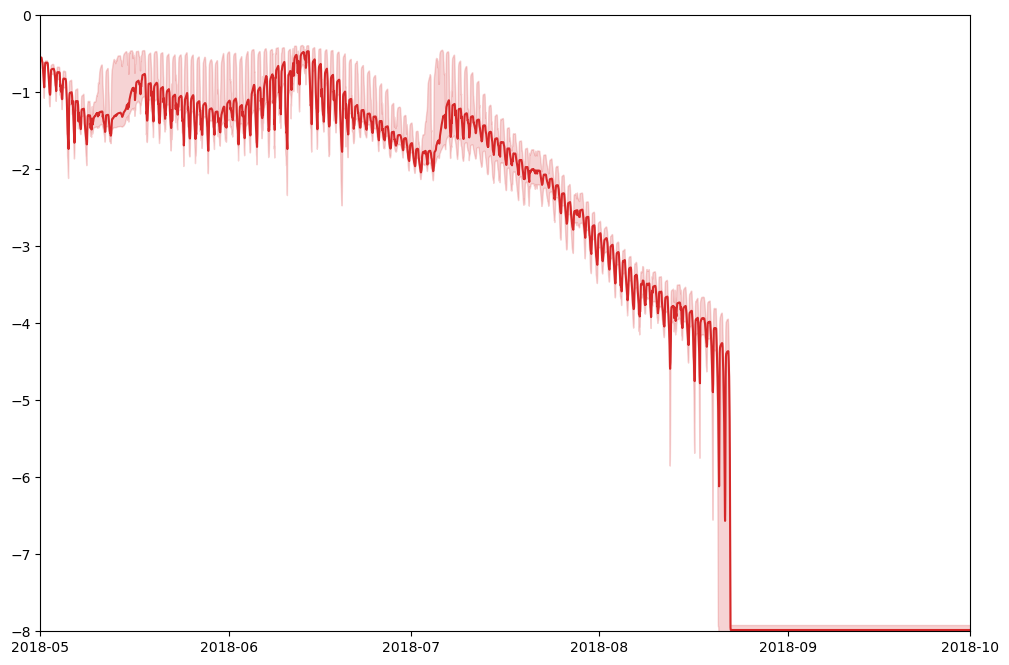

In [26]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(1,1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:red' ,alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-8, 0)

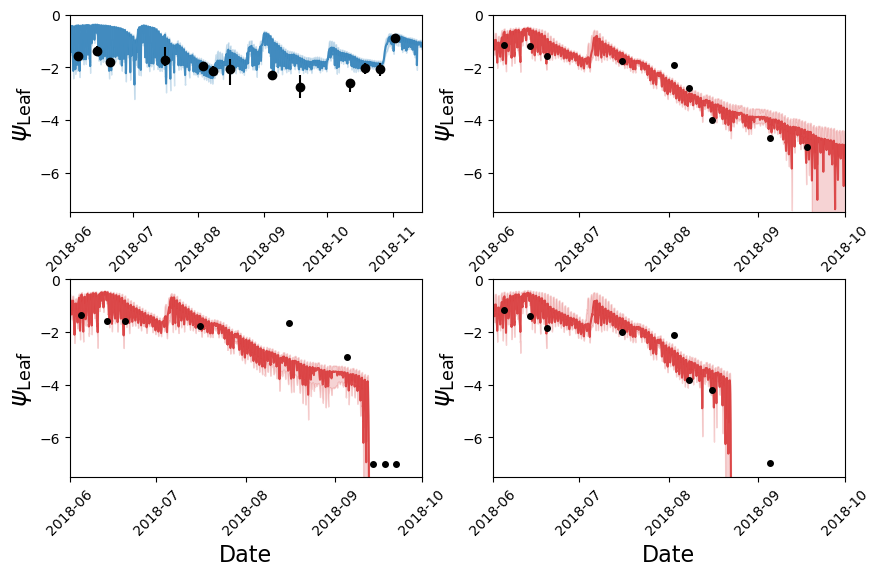

In [10]:
fig = plt.figure(figsize=(10, 6))
import matplotlib.dates as mdates


for i, ii in zip(range(1,5),[1,2,4,5]):
    if ii == 1:
        col = 'tab:blue'
    else:
        col = 'tab:red'
    ax = fig.add_subplot(2, 2, i)
    ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c=col, alpha=0.8)
    ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color=col,
                    alpha=0.2)
    if ii == 1:
        df_tree_mean = trees[ii].groupby(trees[ii].index).mean()
        df_tree_lower = trees[ii].groupby(trees[ii].index).min()
        df_tree_upper = trees[ii].groupby(trees[ii].index).max()
        ax.errorbar(df_tree_mean.index, df_tree_mean['xylem_pressure'], yerr =[df_tree_mean['xylem_pressure']-df_tree_lower['xylem_pressure'],
                                                        df_tree_upper['xylem_pressure'] - df_tree_mean['xylem_pressure']] ,color = 'black', fmt= 'o')
    
    else:
        ax.scatter(trees[ii].index, trees[ii]['xylem_pressure'], color= 'black', zorder =2, s =16)
    if ii == 1:
        ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-11-15'))
    else:
        ax.set_xlim(pd.Timestamp('2018-06-01'), pd.Timestamp('2018-10-1'))
    
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))

    # 4. Format the tick labels to display the month and year
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.set_ylim(-7.5, 0)
    ax.set_xlabel("Date", fontsize=16)
    ax.set_ylabel(r"$\psi_\mathrm{Leaf}$", fontsize=18)
    plt.xticks(rotation=45)
plt.subplots_adjust(hspace=0.34)
plt.savefig(os.path.join(post_path, "F1_ALL.png"), bbox_inches='tight', dpi=300)

(array([17655., 17656., 17657., 17658., 17659., 17660., 17661.]),
 [Text(17655.0, 0, '2018-05-04'),
  Text(17656.0, 0, '2018-05-05'),
  Text(17657.0, 0, '2018-05-06'),
  Text(17658.0, 0, '2018-05-07'),
  Text(17659.0, 0, '2018-05-08'),
  Text(17660.0, 0, '2018-05-09'),
  Text(17661.0, 0, '2018-05-10')])

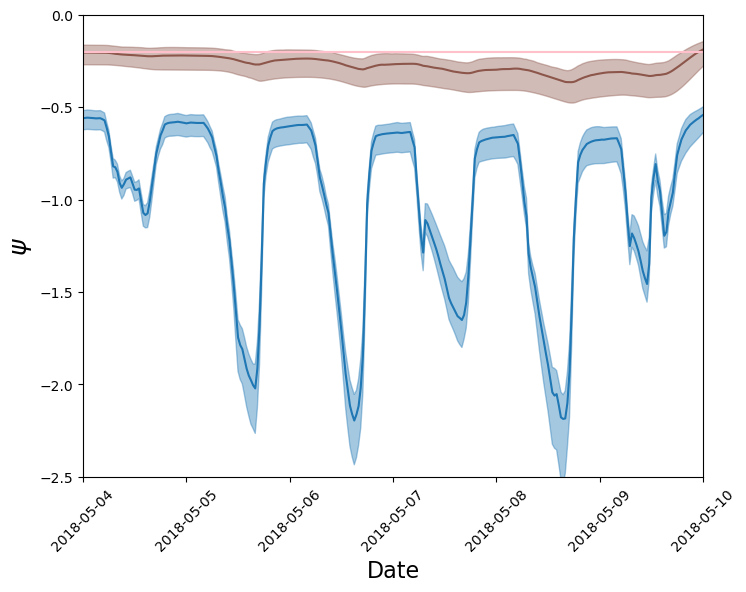

In [11]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder =1, c = 'tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder =1, color = 'tab:blue' ,alpha=0.4)
ax.plot(df_ax_m[ii]['psiSap'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiSap'], df_ax_qu[ii]['psiSap'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.plot(df_ax_m[ii]['psiHeart'], zorder =1, c = 'pink')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiHeart'], df_ax_qu[ii]['psiHeart'], zorder =1, color = 'pink' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-04'), pd.Timestamp('2018-05-10'))
ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)
#plt.savefig(os.path.join(post_path, "F1_P1.png"), bbox_inches='tight', dpi = 300)

(-8.0, 0.0)

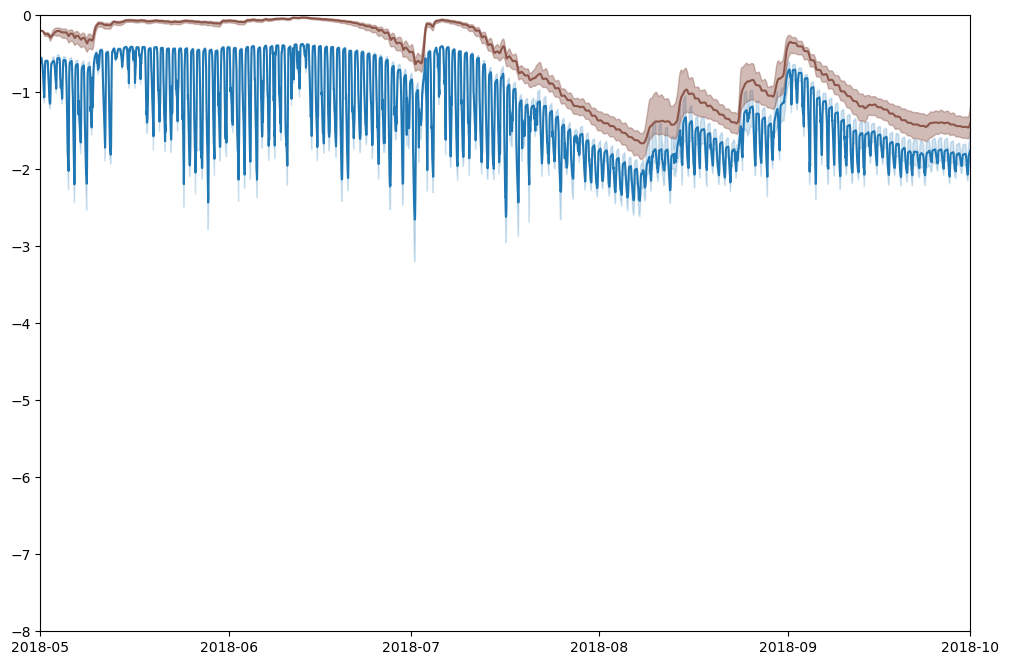

In [12]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 1
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:blue')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:blue',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiSap'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiSap'], df_ax_qu[ii]['psiSap'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-10-1'))
ax.set_ylim(-8, 0)

(-10.0, 0.0)

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

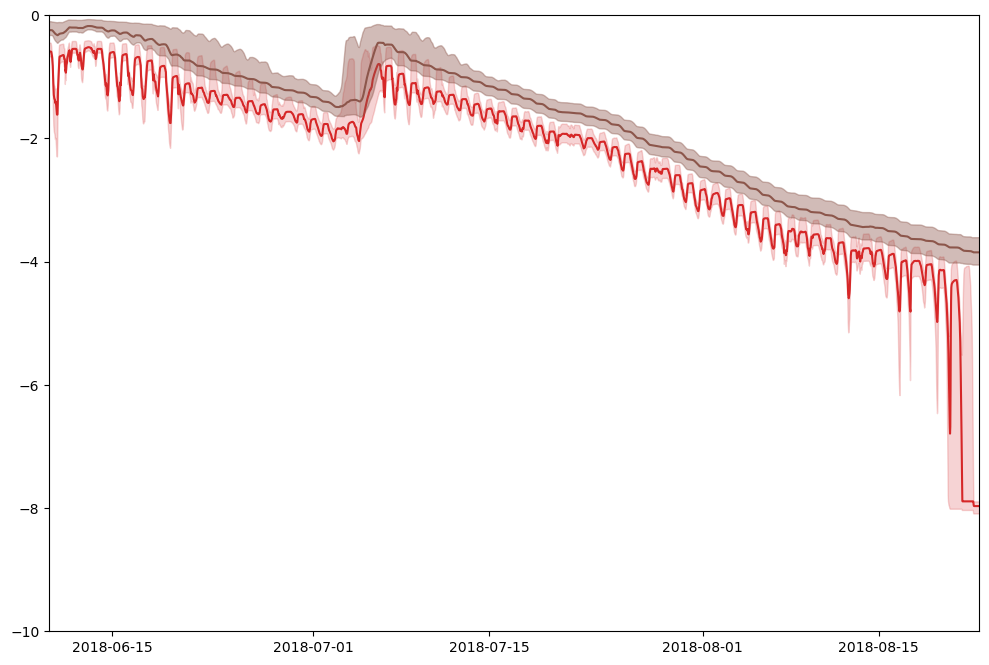

In [73]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiSap'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiSap'], df_ax_qu[ii]['psiSap'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-06-10'), pd.Timestamp('2018-8-23'))
ax.set_ylim(-10, 0)

(-10.0, 0.0)

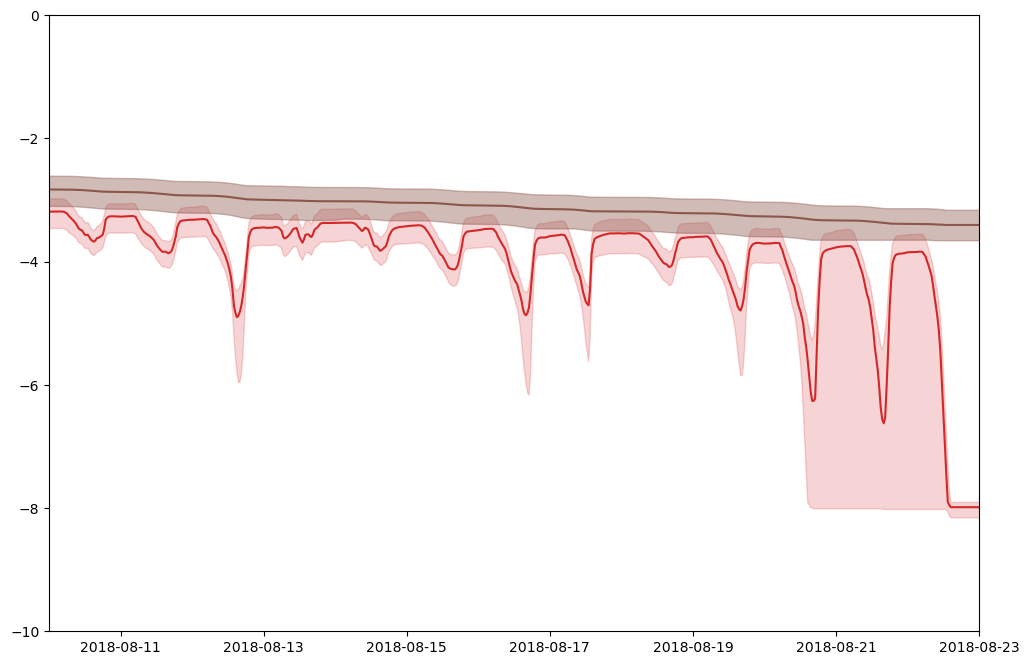

In [13]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiSap'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiSap'], df_ax_qu[ii]['psiSap'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-08-10'), pd.Timestamp('2018-8-23'))
ax.set_ylim(-10, 0)

(array([17720., 17727., 17734., 17744., 17751., 17758., 17765., 17775.,
        17782.]),
 [Text(17720.0, 0, '2018-07-08'),
  Text(17727.0, 0, '2018-07-15'),
  Text(17734.0, 0, '2018-07-22'),
  Text(17744.0, 0, '2018-08-01'),
  Text(17751.0, 0, '2018-08-08'),
  Text(17758.0, 0, '2018-08-15'),
  Text(17765.0, 0, '2018-08-22'),
  Text(17775.0, 0, '2018-09-01'),
  Text(17782.0, 0, '2018-09-08')])

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

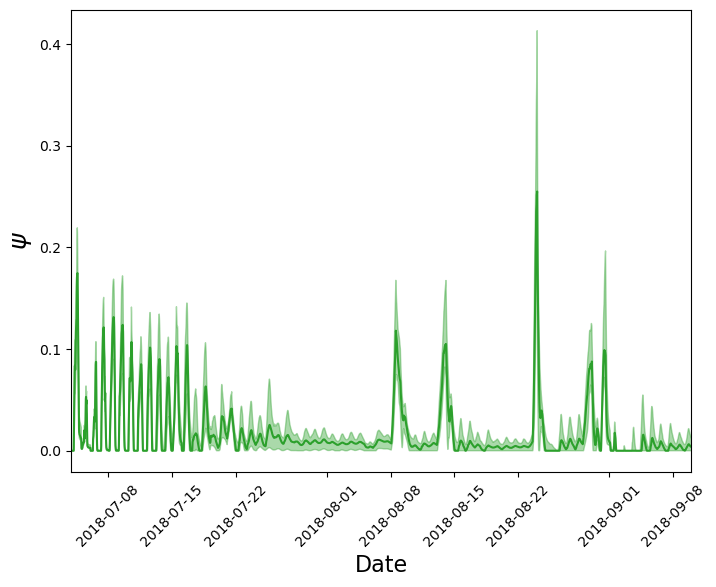

In [30]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['Gs'], zorder =1, c = 'tab:green')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['Gs'], df_ax_qu[ii]['Gs'], zorder = 1, color = 'tab:green' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-07-04'), pd.Timestamp('2018-09-10'))
#ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)

(array([17652., 17666., 17683., 17697., 17713., 17727., 17744., 17758.,
        17775.]),
 [Text(17652.0, 0, '2018-05-01'),
  Text(17666.0, 0, '2018-05-15'),
  Text(17683.0, 0, '2018-06-01'),
  Text(17697.0, 0, '2018-06-15'),
  Text(17713.0, 0, '2018-07-01'),
  Text(17727.0, 0, '2018-07-15'),
  Text(17744.0, 0, '2018-08-01'),
  Text(17758.0, 0, '2018-08-15'),
  Text(17775.0, 0, '2018-09-01')])

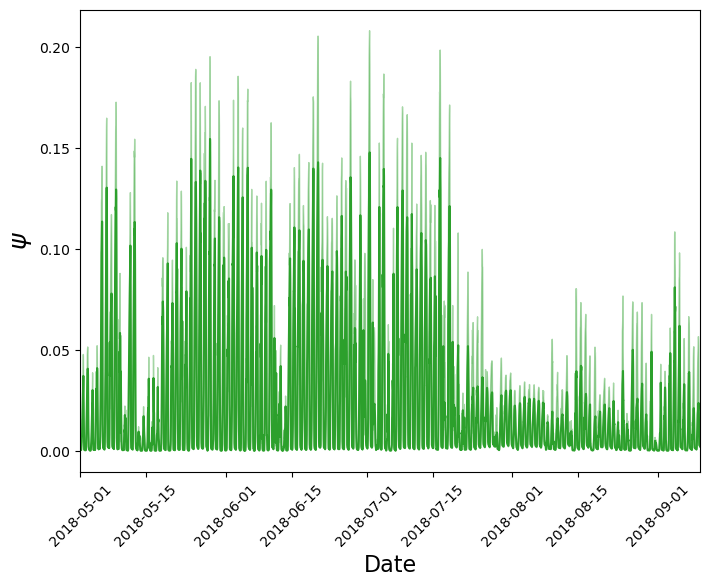

In [30]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 1
ax.plot(df_ax_m[ii]['Js'], zorder =1, c = 'tab:green')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['Js'], df_ax_qu[ii]['Js'], zorder = 1, color = 'tab:green' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-01'), pd.Timestamp('2018-09-10'))
#ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)

(array([17666., 17668., 17670., 17672., 17674., 17676., 17678., 17680.,
        17682., 17683.]),
 [Text(17666.0, 0, '2018-05-15'),
  Text(17668.0, 0, '2018-05-17'),
  Text(17670.0, 0, '2018-05-19'),
  Text(17672.0, 0, '2018-05-21'),
  Text(17674.0, 0, '2018-05-23'),
  Text(17676.0, 0, '2018-05-25'),
  Text(17678.0, 0, '2018-05-27'),
  Text(17680.0, 0, '2018-05-29'),
  Text(17682.0, 0, '2018-05-31'),
  Text(17683.0, 0, '2018-06-01')])

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

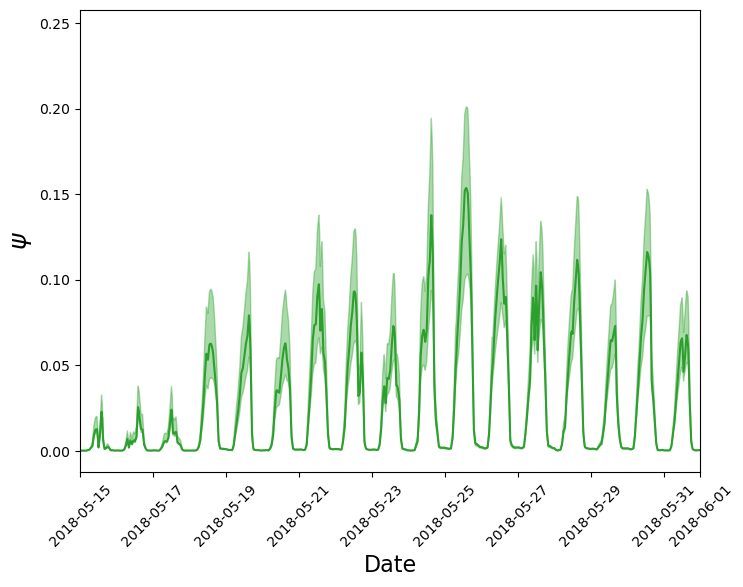

In [36]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(1,1, 1)
ii = 2
ax.plot(df_ax_m[ii]['Js'], zorder =1, c = 'tab:green')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['Js'], df_ax_qu[ii]['Js'], zorder = 1, color = 'tab:green' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-05-15'), pd.Timestamp('2018-06-1'))
#ax.set_ylim(-2.5, 0)
ax.set_xlabel("Date", fontsize = 16)
ax.set_ylabel(r"$\psi$", fontsize = 18)
plt.xticks(rotation=45)

In [ ]:
0.06 * 100/1000*18*1000

108.0

(-10.0, 0.0)

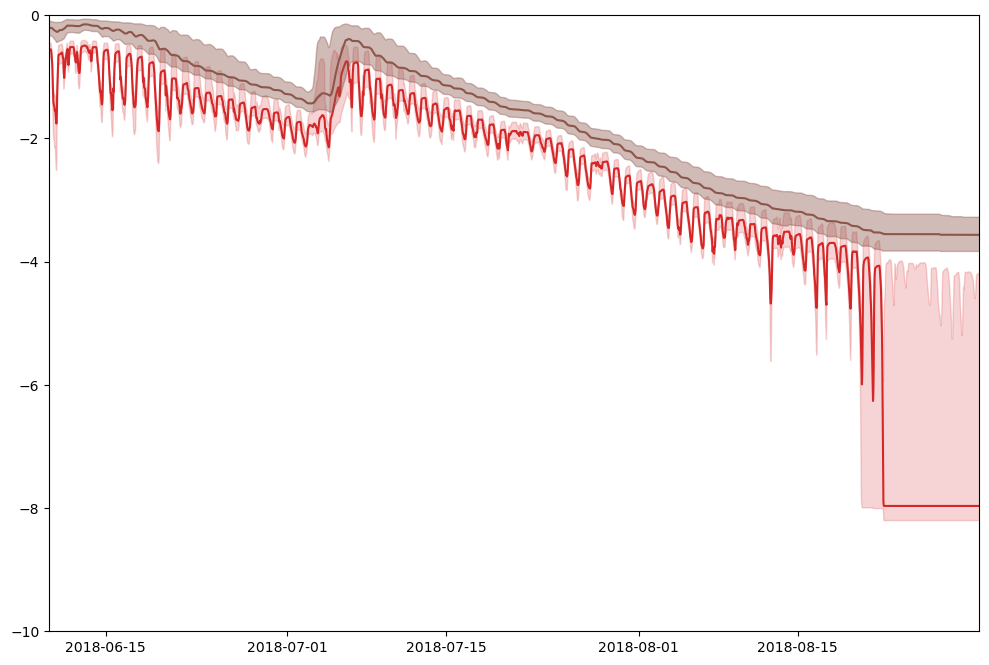

In [19]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 5
ax.plot(df_ax_m[ii]['psiLeaf'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiLeaf'], df_ax_qu[ii]['psiLeaf'], zorder=1, color='tab:red',
                alpha=0.2)
ax.plot(df_ax_m[ii]['psiSap'], zorder =1, c = 'tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['psiSap'], df_ax_qu[ii]['psiSap'], zorder =1, color = 'tab:brown' ,alpha=0.4)
ax.set_xlim(pd.Timestamp('2018-06-10'), pd.Timestamp('2018-8-31'))
ax.set_ylim(-10, 0)

(17727.0, 17774.0)

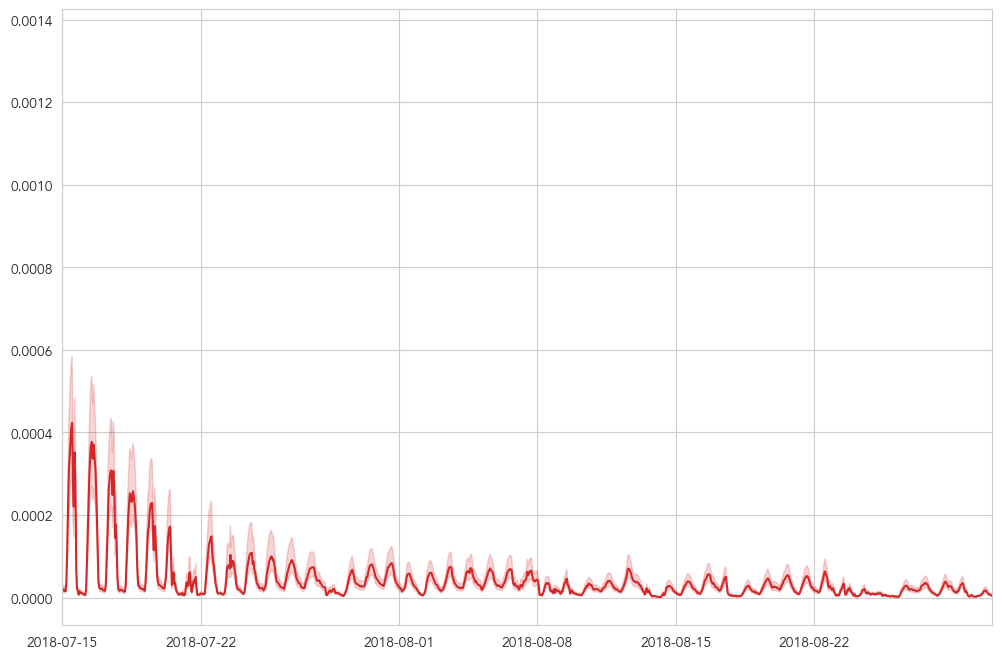

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['T'], zorder=1, c='tab:red')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['T'], df_ax_qu[ii]['T'], zorder=1, color='tab:red',
                alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-07-15'), pd.Timestamp('2018-8-31'))

(np.float64(17727.0), np.float64(17774.0))

findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not found.
findfont: Font family 'Avenir' not

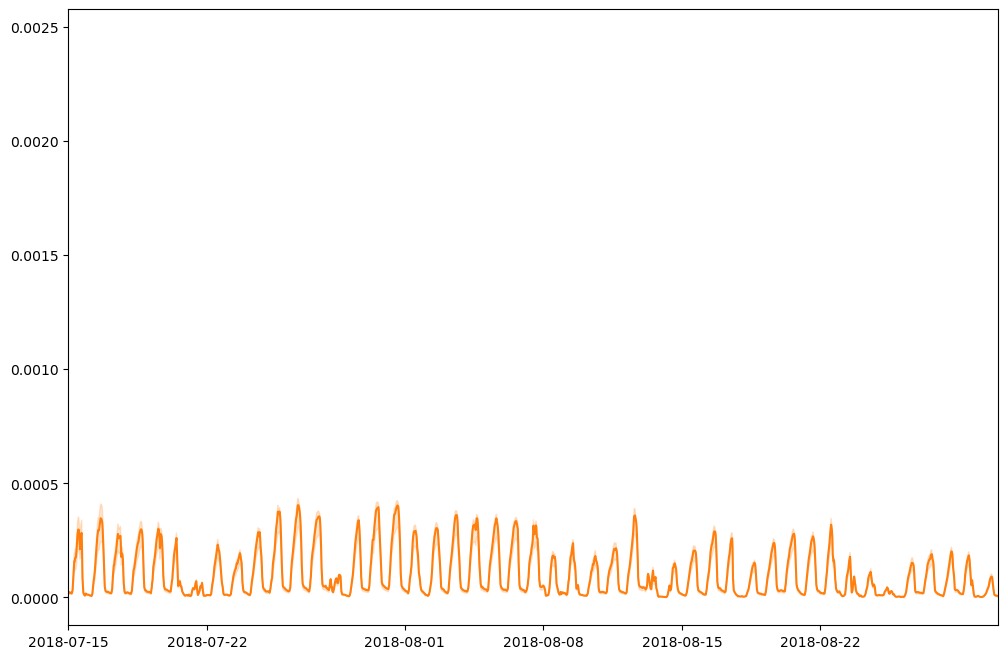

In [38]:
ax.set_ylim(-10, 0)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['J'], zorder=1, c='tab:orange')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['J'], df_ax_qu[ii]['J'], zorder=1, color='tab:orange',
                alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-07-15'), pd.Timestamp('2018-8-31'))

(17727.0, 17774.0)

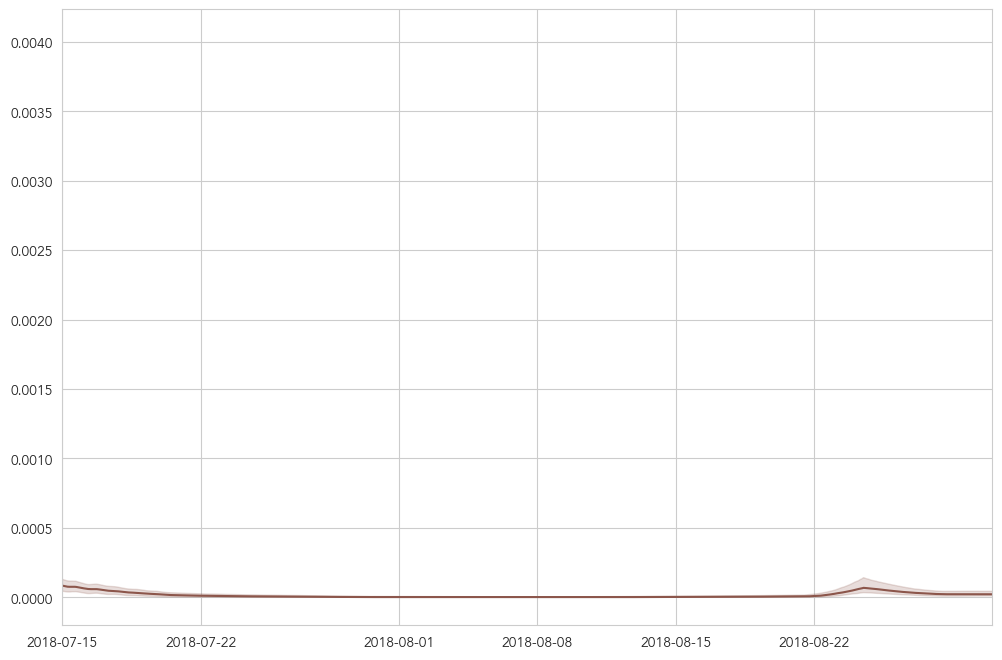

In [ ]:
ax.set_ylim(-10, 0)
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(1, 1, 1)
ii = 2
ax.plot(df_ax_m[ii]['G'], zorder=1, c='tab:brown')
ax.fill_between(df_ax_m[ii].index, df_ax_ql[ii]['G'], df_ax_qu[ii]['G'], zorder=1, color='tab:brown',
                alpha=0.2)
ax.set_xlim(pd.Timestamp('2018-07-15'), pd.Timestamp('2018-8-31'))

In [ ]:
df_ax_m[ii]['T'].mean()

7.204494153350238e-05

In [ ]:
df_ax_m[ii]['T']['2018-07-15':'2018-08-15'].mean()

5.199918513894749e-05

In [ ]:
ii=2
df_ax_m[ii]['vpd']['2018-08-1':'2018-09-01'].mean()

1000.6303757727146

In [ ]:
ii = 2
df_ax_m[ii]['gss']['2018-08-01':'2018-09-01'].mean()

0.0023696906864643097

In [ ]:
ii = 2
df_ax_m[ii]['T']['2018-08-01':'2018-09-01'].mean()

2.3407545689302367e-05

In [ ]:
ii = 2
df_ax_m[ii]['gss']['2018-08-01':'2018-09-01'].mean()

0.0023696906864643097

In [ ]:
ii = 2
df_ax_m[ii]['psiLeaf']['2018-08-01'].min()-df_ax_m[ii]['psiLeaf']['2018-09-01'].min()

1.2117869853973389

In [ ]:
1.2486491203308105 / 31

0.04027900388163905

In [ ]:
ii = 5
df_ax_m[ii]['psiLeaf']['2018-08-01'].min() - df_ax_m[ii]['psiLeaf']['2018-08-15'].min()

1.455795168876648

In [ ]:
1.455795168876648/15

0.09705301125844319

In [ ]:
ii=2
df_ax_m[ii]['vpd']['2018-08-1':'2018-08-15'].mean()

1280.0490270879534